Breast Cancer Wisconsin Dataset
Dataset Shape : (569, 30)

Target Classes
1    357
0    212
Name: count, dtype: int64

Decision Tree Accuracy: 0.9385964912280702
Random Forest Accuracy: 0.956140350877193


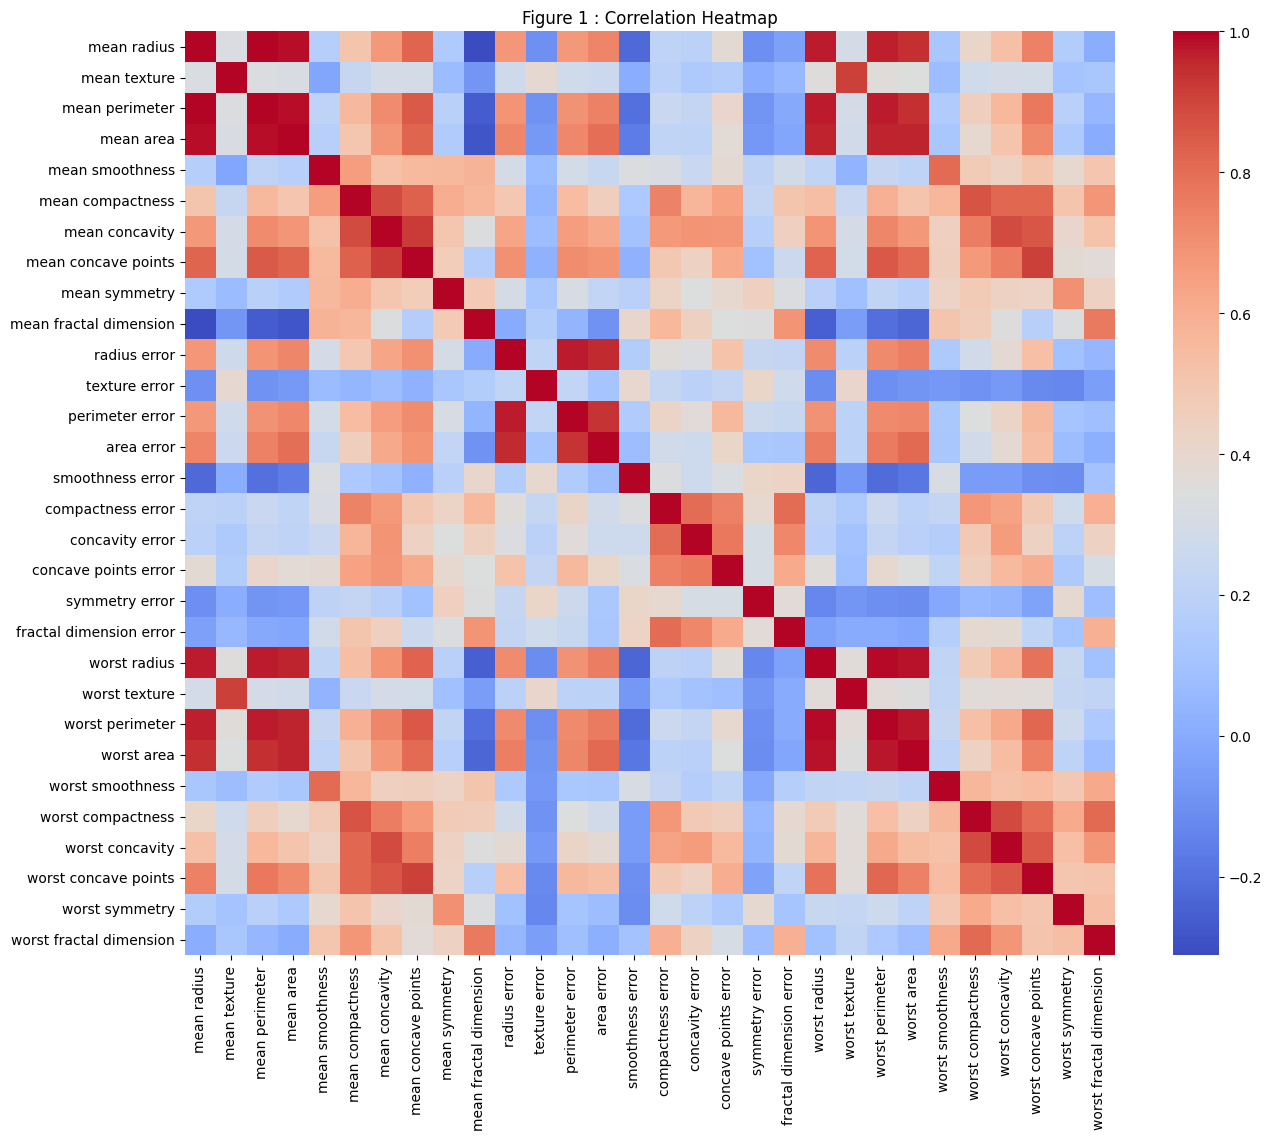

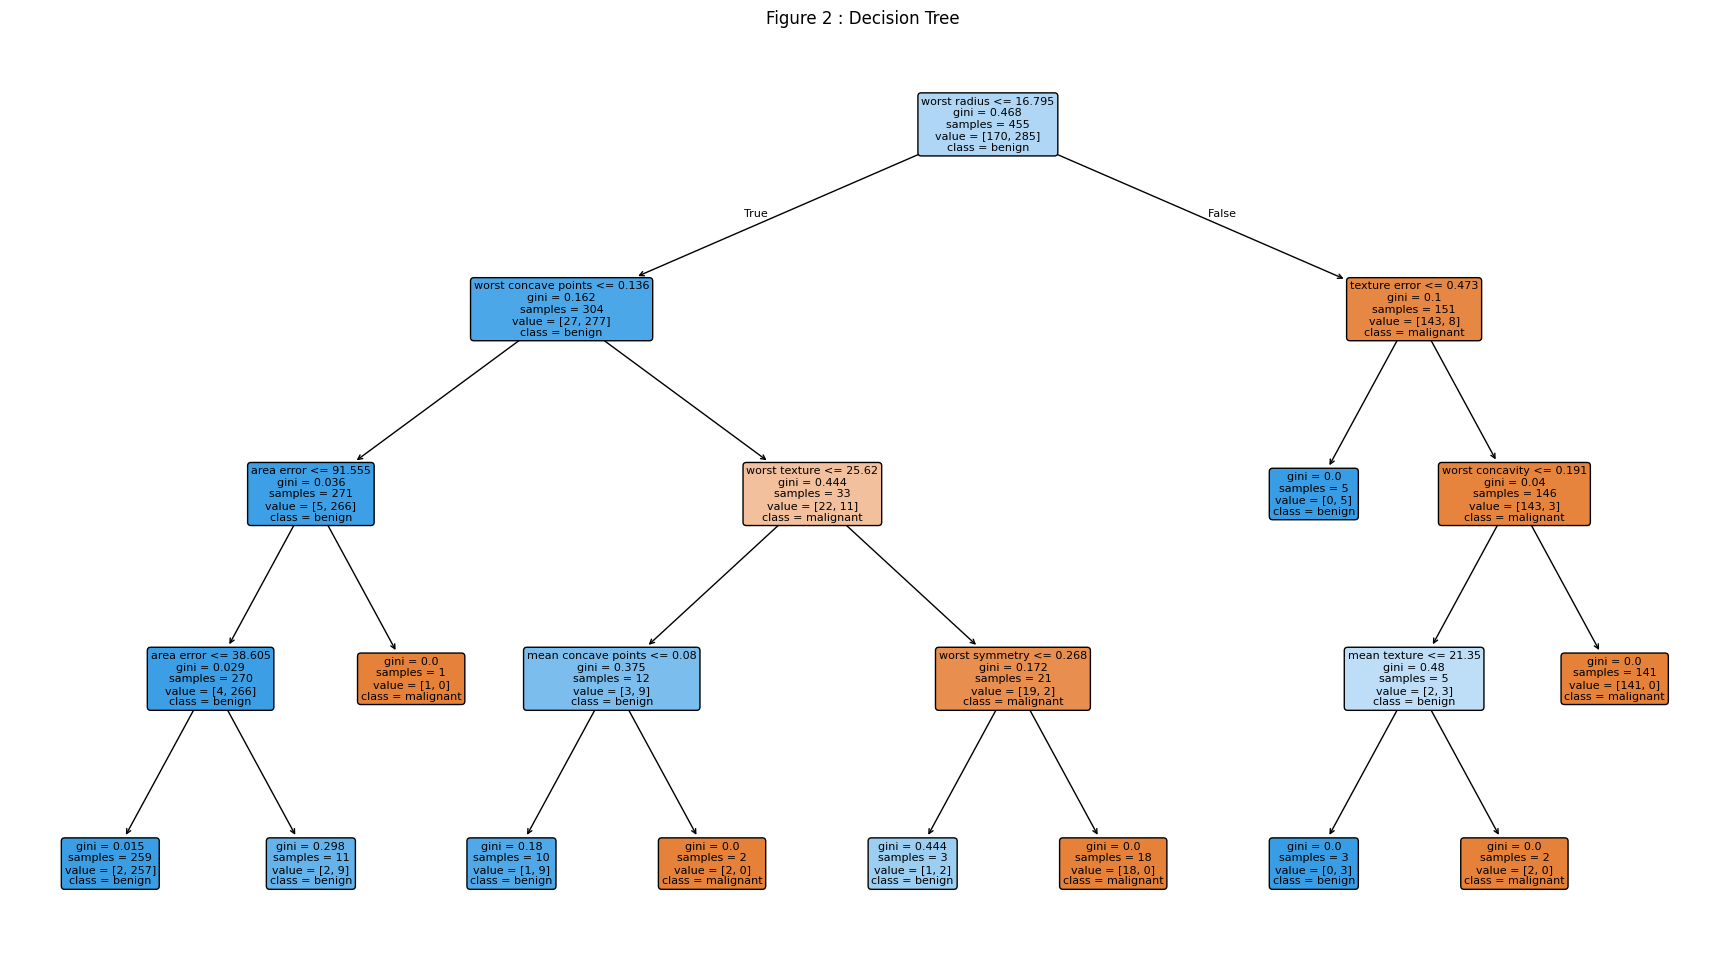

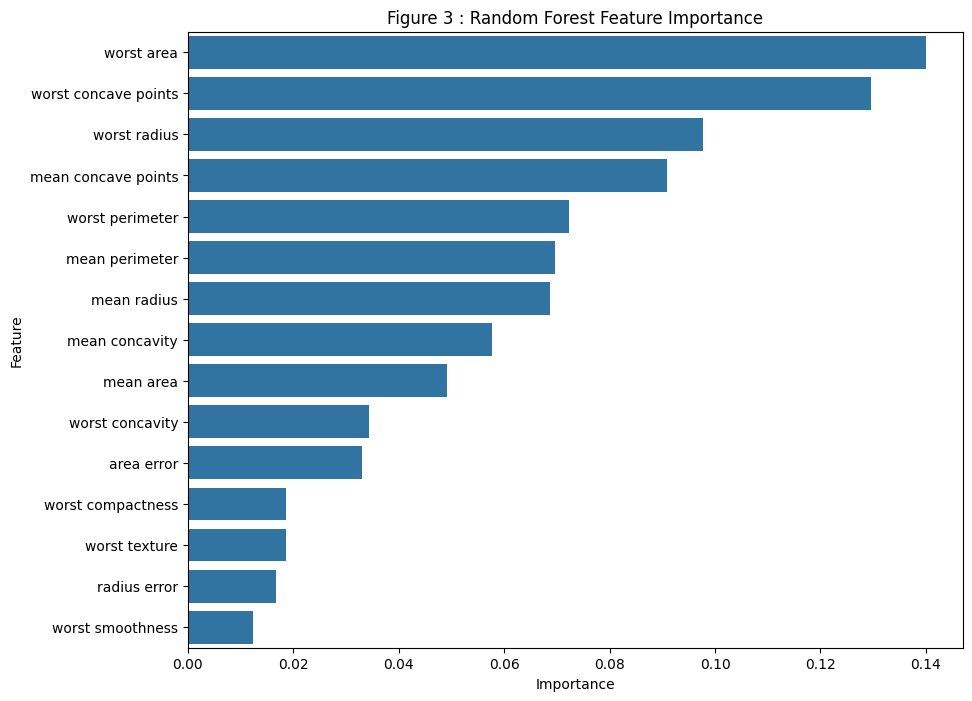

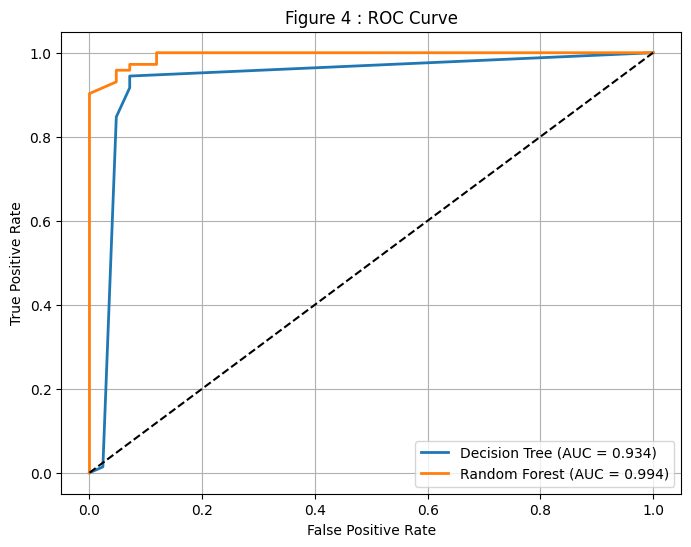


Decision Tree Confusion Matrix


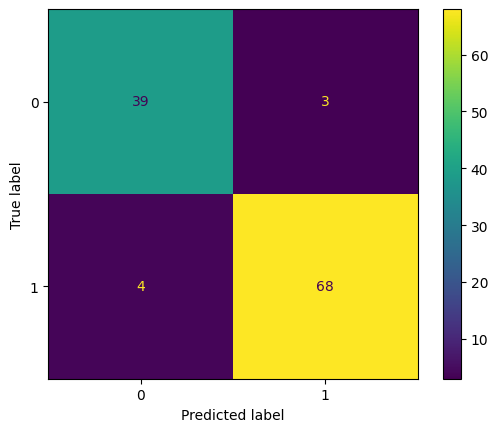


Random Forest Confusion Matrix


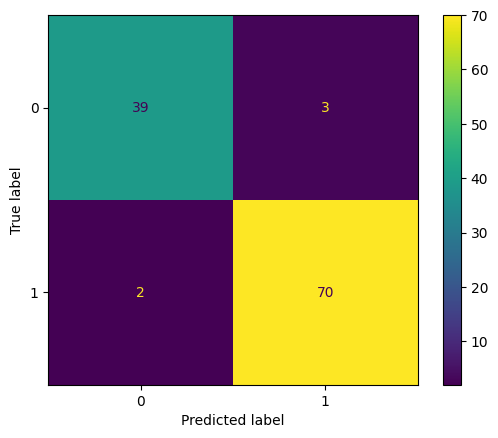



MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.938596   0.957746  0.944444  0.951049
1  Random Forest  0.956140   0.958904  0.972222  0.965517


In [1]:
# ============================================================
# BREAST CANCER WISCONSIN DATASET - COMPLETE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# ============================================================
# LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("="*60)
print("Breast Cancer Wisconsin Dataset")
print("="*60)

print("Dataset Shape :", X.shape)
print("\nTarget Classes")
print(pd.Series(y).value_counts())

# ============================================================
# SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# DECISION TREE
# ============================================================

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("\nDecision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

# ============================================================
# RANDOM FOREST
# ============================================================

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, forest_pred))

# ============================================================
# GRAPH 1 : CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Figure 1 : Correlation Heatmap")

plt.show()

# ============================================================
# GRAPH 2 : DECISION TREE
# ============================================================

plt.figure(figsize=(22,12))

plot_tree(
    tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Figure 2 : Decision Tree")

plt.show()

# ============================================================
# GRAPH 3 : FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Figure 3 : Random Forest Feature Importance")

plt.show()

# ============================================================
# GRAPH 4 : ROC CURVE
# ============================================================

tree_prob = tree.predict_proba(X_test)[:,1]
forest_prob = forest.predict_proba(X_test)[:,1]

tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_prob)
forest_fpr, forest_tpr, _ = roc_curve(y_test, forest_prob)

tree_auc = auc(tree_fpr, tree_tpr)
forest_auc = auc(forest_fpr, forest_tpr)

plt.figure(figsize=(8,6))

plt.plot(
    tree_fpr,
    tree_tpr,
    label="Decision Tree (AUC = %.3f)" % tree_auc,
    linewidth=2
)

plt.plot(
    forest_fpr,
    forest_tpr,
    label="Random Forest (AUC = %.3f)" % forest_auc,
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Figure 4 : ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\nDecision Tree Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred
)

plt.show()

print("\nRandom Forest Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_pred
)

plt.show()

# ============================================================
# MODEL COMPARISON
# ============================================================

results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ],

    "Precision":[
        precision_score(y_test, tree_pred),
        precision_score(y_test, forest_pred)
    ],

    "Recall":[
        recall_score(y_test, tree_pred),
        recall_score(y_test, forest_pred)
    ],

    "F1 Score":[
        f1_score(y_test, tree_pred),
        f1_score(y_test, forest_pred)
    ]

})

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(results)